In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('./data/GlobalLandTemperaturesByCountry.csv')

print(df.isnull().sum())
print(df.isnull().mean())

df['dt']=pd.to_datetime(df["dt"])
df["year"]=df["dt"].dt.year


dt                                   0
AverageTemperature               32651
AverageTemperatureUncertainty    31912
Country                              0
dtype: int64
dt                               0.000000
AverageTemperature               0.056542
AverageTemperatureUncertainty    0.055263
Country                          0.000000
dtype: float64


In [29]:
###数据清理
df=df.dropna(subset=["AverageTemperature"])

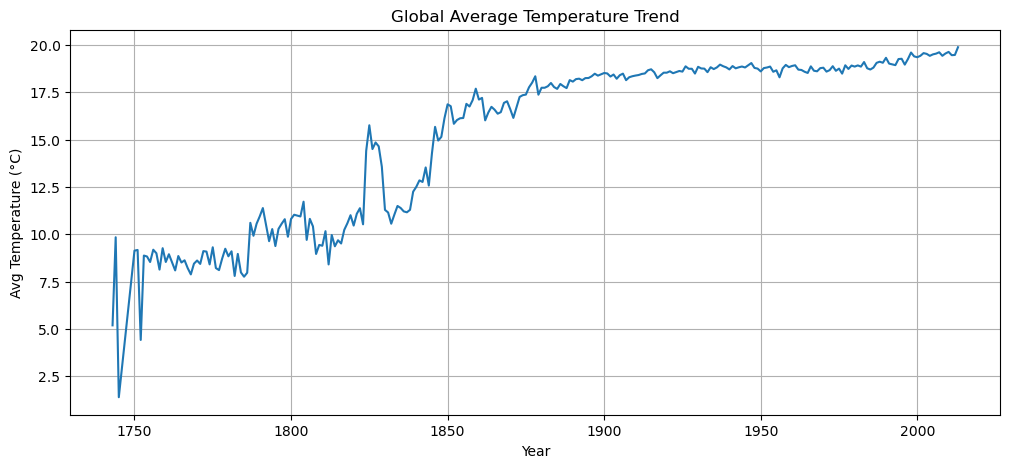

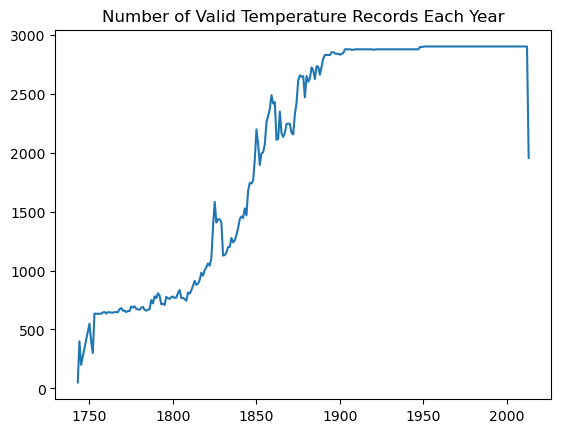

In [30]:
###温度趋势
global_temp=df.groupby("year")["AverageTemperature"].mean()
plt.figure(figsize=(12,5))
plt.plot(global_temp.index,global_temp.values)
plt.title("Global Average Temperature Trend")
plt.xlabel('Year')
plt.ylabel("Avg Temperature (°C)")
plt.grid(True)
plt.show()
years_counts = df.groupby("year")["AverageTemperature"].count()#每年平均温度的数量
plt.plot(years_counts.index, years_counts.values)
plt.title("Number of Valid Temperature Records Each Year")
plt.show()

In [31]:
valid_years=years_counts[years_counts>50].index#每年平均温度数量大于50的每年平均温度的index
df_min50 = df[df["year"].isin(valid_years)]#平均温度大于50的年份

global_temp = df_min50.groupby("year")["AverageTemperature"].mean()#每年的国家测量的温度平均，代表该年的平均温度
rolling = global_temp.rolling(window=10, center=True).mean()
threshold = 3
mask = (global_temp - rolling).abs() < threshold
clean_temp = global_temp[mask]#进一步去除噪点

df_clear = df_min50[df_min50["year"].isin(clean_temp.index)]#测量数大于50且去除噪点的年份

df_clear.head()#latitude是纬度，横着的那个

,dt,AverageTemperature,AverageTemperatureUncertainty,Country,year
110,1753-01-01,-2.412,8.018,Åland,1753
111,1753-02-01,-3.273,3.736,Åland,1753
112,1753-03-01,0.710,4.638,Åland,1753
113,1753-04-01,2.778,5.138,Åland,1753
114,1753-05-01,6.226,3.150,Åland,1753


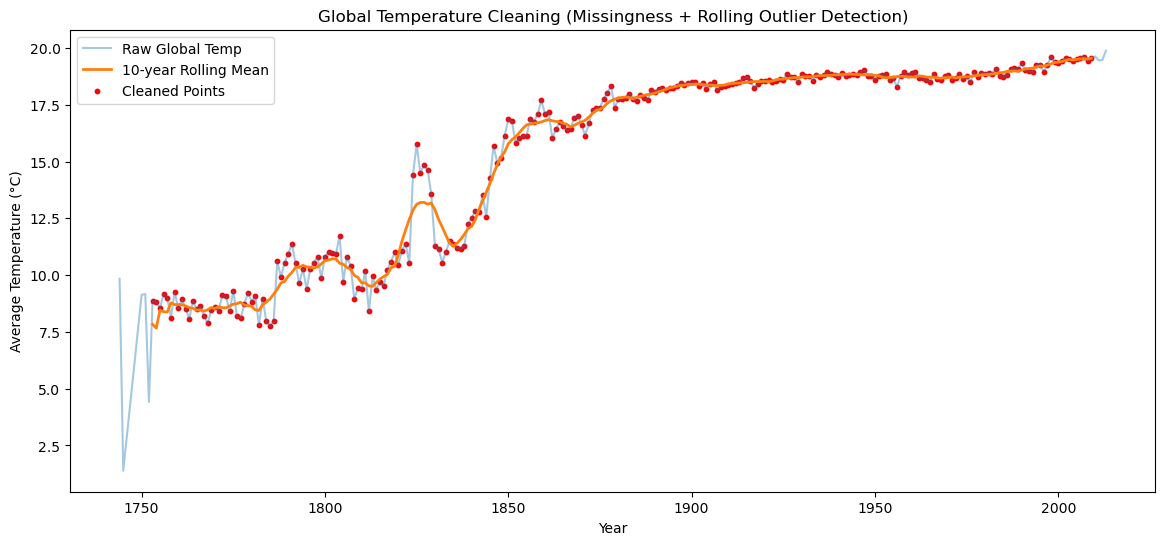

In [32]:

plt.figure(figsize=(14,6))
plt.plot(global_temp.index, global_temp.values, label="Raw Global Temp", alpha=0.4)#
plt.plot(rolling.index, rolling.values, label="10-year Rolling Mean", linewidth=2)#窗口滑动的平均值
plt.scatter(clean_temp.index, clean_temp.values, label="Cleaned Points", color='red', s=10)
plt.legend()
plt.title("Global Temperature Cleaning (Missingness + Rolling Outlier Detection)")
plt.xlabel("Year")
plt.ylabel("Average Temperature (°C)")
plt.show()


- 出现了不符合事实的情况：1800年左右先升后降
    需要事实：真实全球温度变化不会在 20 年内突然升降 2°C 以上
    再去研究数据存在的真实原因：
    1. 看图发现新增了很多数据，可能在热带地区修了观测点
    2. >数据插补（imputation）算法导致的虚假趋势
    
    解决方向：
    1. 首先定位真实原因，发现国家不同了，见下
    2. 剔除1880年之前的数据

In [33]:
##判断数据来源
for year in range(1790, 1821):  
    print(f"\n===== Year {year} =====")
    
    df_year = df[df["year"] == year]["Country"].value_counts()
    
    if df_year.empty:
        print("No data available.")
    else:
        print(df_year.head(5))




===== Year 1790 =====
Country
Åland      12
Albania    12
Algeria    12
Andorra    12
Austria    12
Name: count, dtype: int64

===== Year 1791 =====
Country
Åland      12
Albania    12
Algeria    12
Andorra    12
Armenia    12
Name: count, dtype: int64

===== Year 1792 =====
Country
Åland      12
Albania    12
Algeria    12
Andorra    12
Armenia    12
Name: count, dtype: int64

===== Year 1793 =====
Country
Åland      12
Albania    12
Algeria    12
Andorra    12
Austria    12
Name: count, dtype: int64

===== Year 1794 =====
Country
Åland      12
Albania    12
Algeria    12
Andorra    12
Austria    12
Name: count, dtype: int64

===== Year 1795 =====
Country
Åland      12
Albania    12
Andorra    12
Austria    12
Belarus    12
Name: count, dtype: int64

===== Year 1796 =====
Country
Åland      12
Albania    12
Algeria    12
Andorra    12
Austria    12
Name: count, dtype: int64

===== Year 1797 =====
Country
Åland      12
Albania    12
Algeria    12
Andorra    12
Austria    12
Name: coun

1796年之后加入了很多印度4356，远超美俄1600，1400

但是之后十多年数据量几乎不变很显然并不合理，推测是插值算法的改变

---

不是观测导致的变化
而是“空间重建模型”本身在变化
>1796：插值模型高估印度 → 全球均值上升

>1805：插值模型下调估计 → 全球均值下降

从下图，可以看出1880年之后参与国家数恒定，因此我们线性规划剔除1880年之前的数据

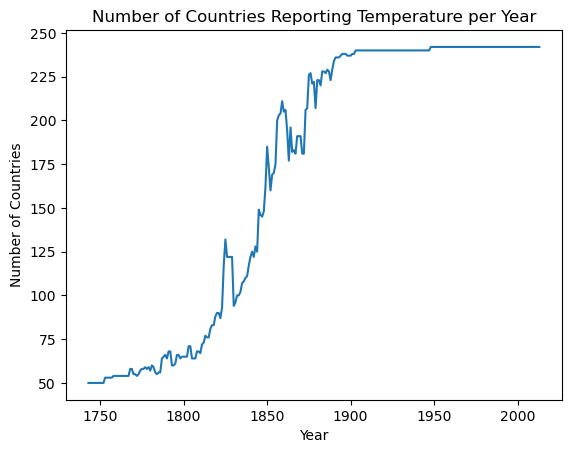

In [34]:
countries_per_year = df.groupby("year")["Country"].nunique()

plt.plot(countries_per_year)
plt.title("Number of Countries Reporting Temperature per Year")
plt.xlabel("Year")
plt.ylabel("Number of Countries")
plt.show()


In [35]:
###做线性回归
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
global_temp_1880 = df[df["year"] >= 1880].groupby("year")["AverageTemperature"].mean()

# 去除 NaN 年份
global_temp_1880 = global_temp_1880.dropna()

rolling = global_temp_1880.rolling(10, center=True).mean()
diff = (global_temp_1880 - rolling).abs()

# 自动剔除偏离超过 1.5°C 的点
clean_temp = global_temp_1880[diff < 1.5]#大于1880年，且去除噪点的年份的数据

# 拆分 X, y
years = clean_temp.index.values.reshape(-1, 1)#转化为2维数组，机器学习要求输入特征必须是二维数组
temps = clean_temp.values 

model=LinearRegression()
model.fit(years,temps)
predicted=model.predict(years)
last_year = years.max()
future_years = np.arange(last_year+1, last_year+31).reshape(-1, 1)
future_pred = model.predict(future_years)

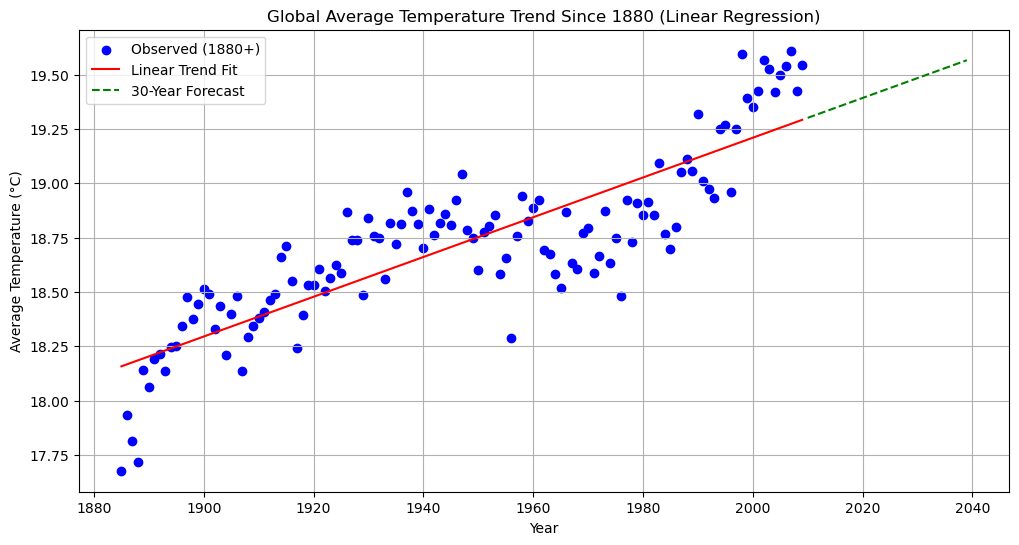

In [36]:
###模型评估
plt.figure(figsize=(12,6))

plt.scatter(years, temps, color='blue', label="Observed (1880+)")
plt.plot(years, predicted, color='red', label="Linear Trend Fit")
plt.plot(future_years, future_pred, color='green', linestyle='--', 
         label="30-Year Forecast")

plt.title("Global Average Temperature Trend Since 1880 (Linear Regression)")
plt.xlabel("Year")
plt.ylabel("Average Temperature (°C)")
plt.legend()
plt.grid(True)
plt.show()


In [37]:
r2 = r2_score(temps, predicted)
rmse = np.sqrt(mean_squared_error(temps, predicted))

print("R-squared:", r2)
print("RMSE:", rmse)


R-squared: 0.7279472256694755
RMSE: 0.20186071469399172


你可以总结成一句非常专业的话：

“Although global temperature records exist since 1850, the data only become globally representative and statistically stable after 1880. Therefore, we decided to use data from 1880 onwards for regression, clustering, and visualization to ensure that our results reflect real climatological trends rather than sampling bias.”

更加通俗但专业：

“1880 年之后，世界各地区的气象站数量趋于稳定，南半球数据完善，因此更适合建模和聚类。”

In [38]:
from sklearn.cluster import KMeans
df_1880 = df[df["year"] >= 1880]

# 按国家计算特征
country_features = df_1880.groupby("Country")["AverageTemperature"].agg(
    mean_temp="mean",
    std_temp="std"
).dropna()

country_features.head()

,mean_temp,std_temp
Country,,
Afghanistan,14.148352,9.220790
Africa,24.148696,1.753997
Albania,12.794414,6.899446
Algeria,23.174480,7.716467
American Samoa,26.636906,0.612490


In [43]:
from sklearn.preprocessing import StandardScaler

# 标准化特征
scaler = StandardScaler()
X_scaled = scaler.fit_transform(country_features)

# KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

country_features["cluster"] = clusters


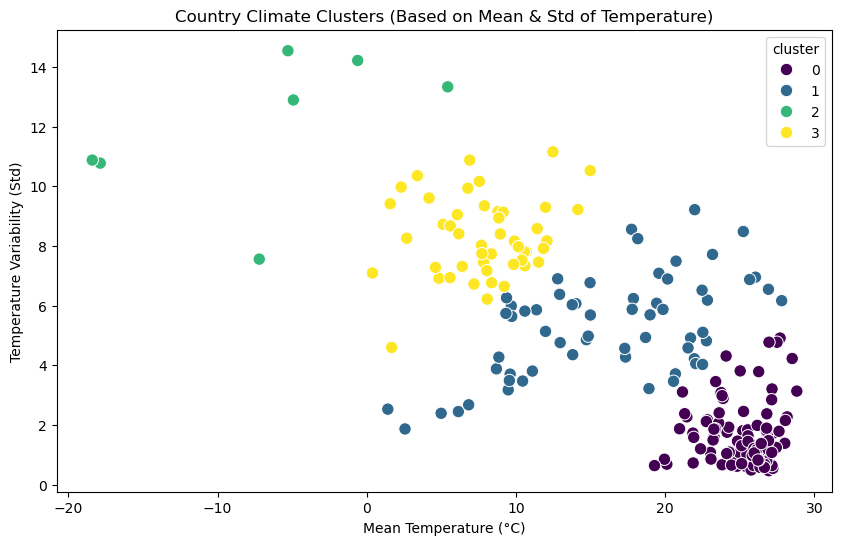

In [44]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=country_features,
    x="mean_temp",
    y="std_temp",
    hue="cluster",
    palette="viridis",
    s=80
)

plt.title("Country Climate Clusters (Based on Mean & Std of Temperature)")
plt.xlabel("Mean Temperature (°C)")
plt.ylabel("Temperature Variability (Std)")
plt.show()


In [45]:
import plotly.express as px

# 重置 index 以便 Choropleth 使用
country_map = country_features.reset_index()

fig = px.choropleth(
    country_map,
    locations="Country",
    locationmode="country names",
    color="cluster",             # 也可以换成 "mean_temp"
    hover_name="Country",
    hover_data=["mean_temp", "std_temp"],
    color_continuous_scale=px.colors.sequential.Viridis,
    title="Climate Clusters of Countries (Based on 1880+ Temperature Mean & Std)"
)

fig.update_layout(
    geo=dict(showframe=False, showcoastlines=True),
    title_x=0.5
)

fig.show()


/tmp/ipykernel_1363/3811889290.py:6: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.

